# Random Forest Project
## Diabetes Prediction using Ensembles
MSalaverri

We want to improve diabetes prediction by training a Random Forest model combining multiple trees to reduce overfitting and increase accuracy on the processed dataset from the previous Decision Tree project.

*Type of Problem:* **classification problem** problem using **Random Forest.**

In [31]:
# IMPORT LIBRARIES

# Data manipulation & visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split

# Modeling
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,confusion_matrix, classification_report, roc_auc_score, mean_squared_error,r2_score
)

# Saving the model
import joblib

In [32]:
# LOADING ORIGINAL DATA
data = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(data)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Exploratory Data Analysis

In [33]:
#Dataset dimension
rows, column = df.shape
print("DATASET Dimension:")
print(f'{rows} rows and {column} columns')

DATASET Dimension:
768 rows and 9 columns


In [34]:
# Get information about range index, number of columns and labels, data types, and the number of cells in each column (non-null values)
print("DATASET General Info:")
df.info()

DATASET General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [35]:
#List Missing values
all_missing_values = df.isnull().sum()
print("Null Values per Column:")
all_missing_values.reset_index()


Null Values per Column:


,index,0
0,Pregnancies,0
1,Glucose,0
2,BloodPressure,0
3,SkinThickness,0
4,Insulin,0
5,BMI,0
6,DiabetesPedigreeFunction,0
7,Age,0
8,Outcome,0


In [36]:
num_of_zeros = (df == 0).sum()
print("Count of Zeros per Column:")
num_of_zeros.sort_values(ascending=False).reset_index()

Count of Zeros per Column:


,index,0
0,Outcome,500
1,Insulin,374
2,SkinThickness,227
3,Pregnancies,111
4,BloodPressure,35
5,BMI,11
6,Glucose,5
7,DiabetesPedigreeFunction,0
8,Age,0


### Initial Inspection Summary

The dataset contains 768 rows and 9 columns, each row representing a patient with diagnostic measurements related to diabetes.

All columns are fully populated, with no missing values reported, but there are a large number of **Zeros** identified in *SkinThickness* and *Insulin* columns, as well as *BloodPressure* column that can't have 0 values. We'll need to handle or impute later on.

The dataset includes:

- 7 integer features (e.g., Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, Age, Outcome)
- 2 float features (BMI, DiabetesPedigreeFunction)

**Outcome** is the target variable: 0 means no diabetes, 1 means positive diagnosis.

## 2. Data Prep

### Only Missing Values

In [37]:
only_missing_values_columns = all_missing_values[all_missing_values > 0]
print("Only Missing Values Columns:")
only_missing_values_columns.reset_index()

Only Missing Values Columns:


,index,0


### Duplicates

In [38]:
#Looking for Duplicates
duplicates = df.duplicated()
sum_duplicates = duplicates.sum()

# VERIFICACION DE DUPLICADOS
print(f"Duplicated Rows: {sum_duplicates}")

Duplicated Rows: 0


No duplicates present

### Replace invalid Zeros with NaN
(Not a number) excluding pregnancies

In [39]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

#Median Imputation
for col in cols_with_zeros:
    df.fillna({col: df[col].median()}, inplace=True)

In [40]:
#After Imputing
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Visualizations and Data Analysis

In [41]:
#Show Unique values per column name
n_uniques = df.nunique()
n_uniques.reset_index()

,index,0
0,Pregnancies,17
1,Glucose,135
2,BloodPressure,46
3,SkinThickness,50
4,Insulin,185
5,BMI,247
6,DiabetesPedigreeFunction,517
7,Age,52
8,Outcome,2


### Univariate Plots

#### Target Variable Distribution

*Note:* Target Variable is **Outcome**

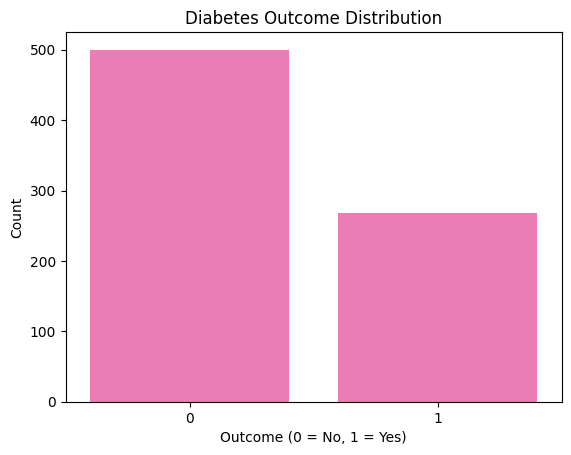

,Outcome,proportion
0,0,65.104167
1,1,34.895833


In [42]:
# Target (0 = no diabetes, 1 = diabetes).

sns.countplot(data=df, x='Outcome', color="hotpink")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

(df['Outcome'].value_counts(normalize=True)*100).reset_index()

#### Numeric Features Distribution

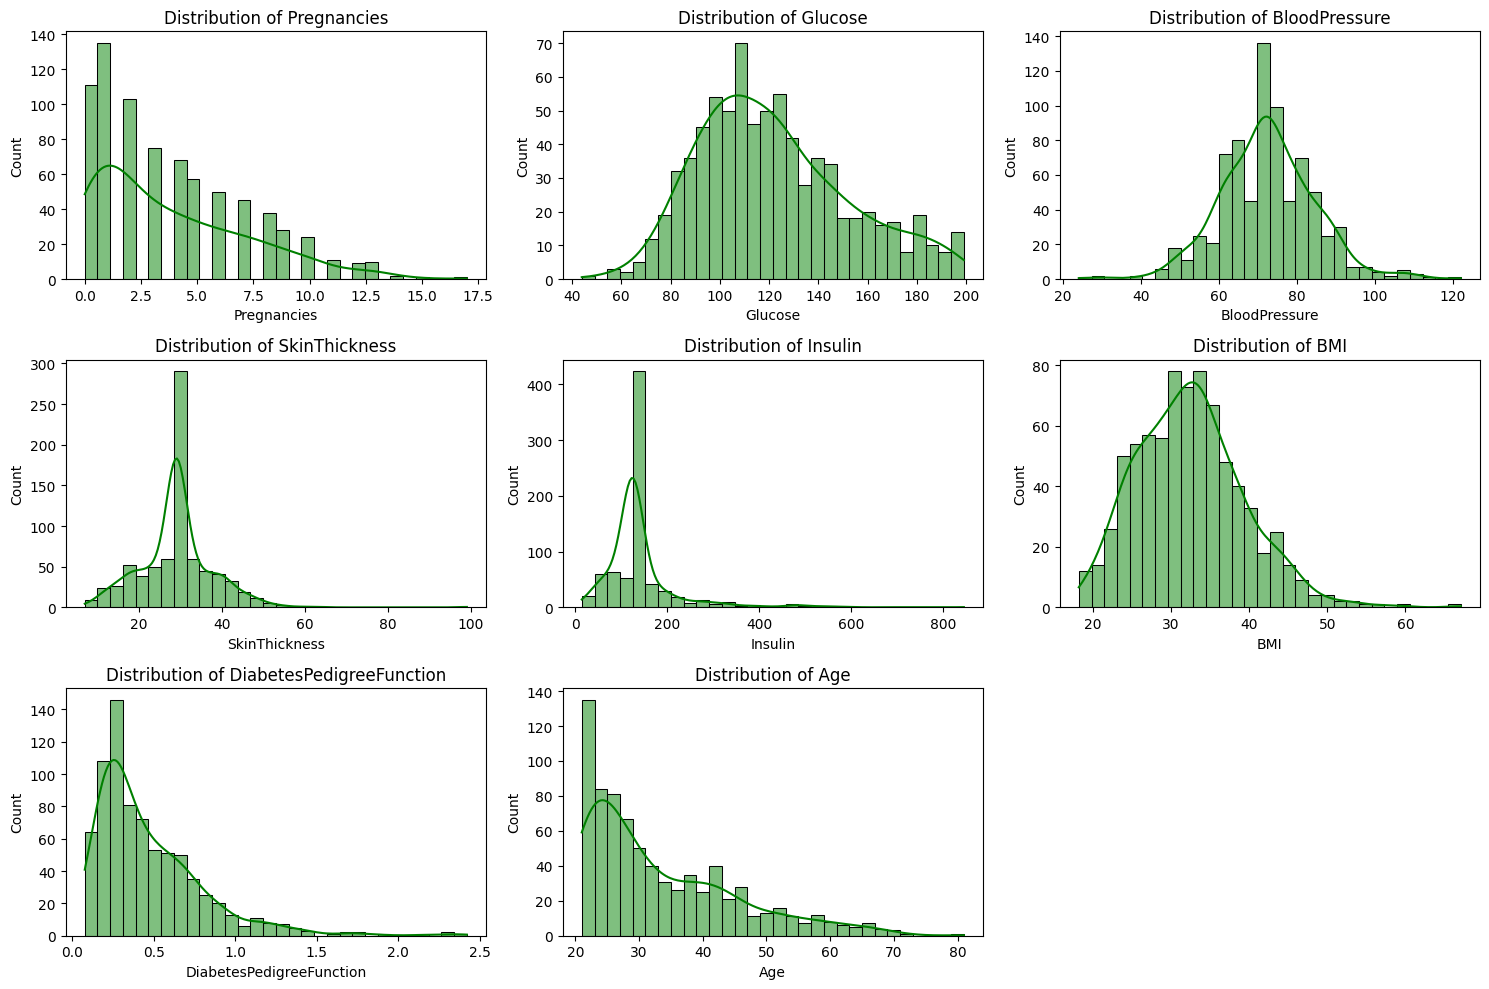

In [43]:
num_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns='Outcome', axis=1).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color="green")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### Bivariate Plots

#### Numeric Features vs Target Variable

*Note:* Target variable is **Outcome** (0 = no diabetes, 1 = diabetes)

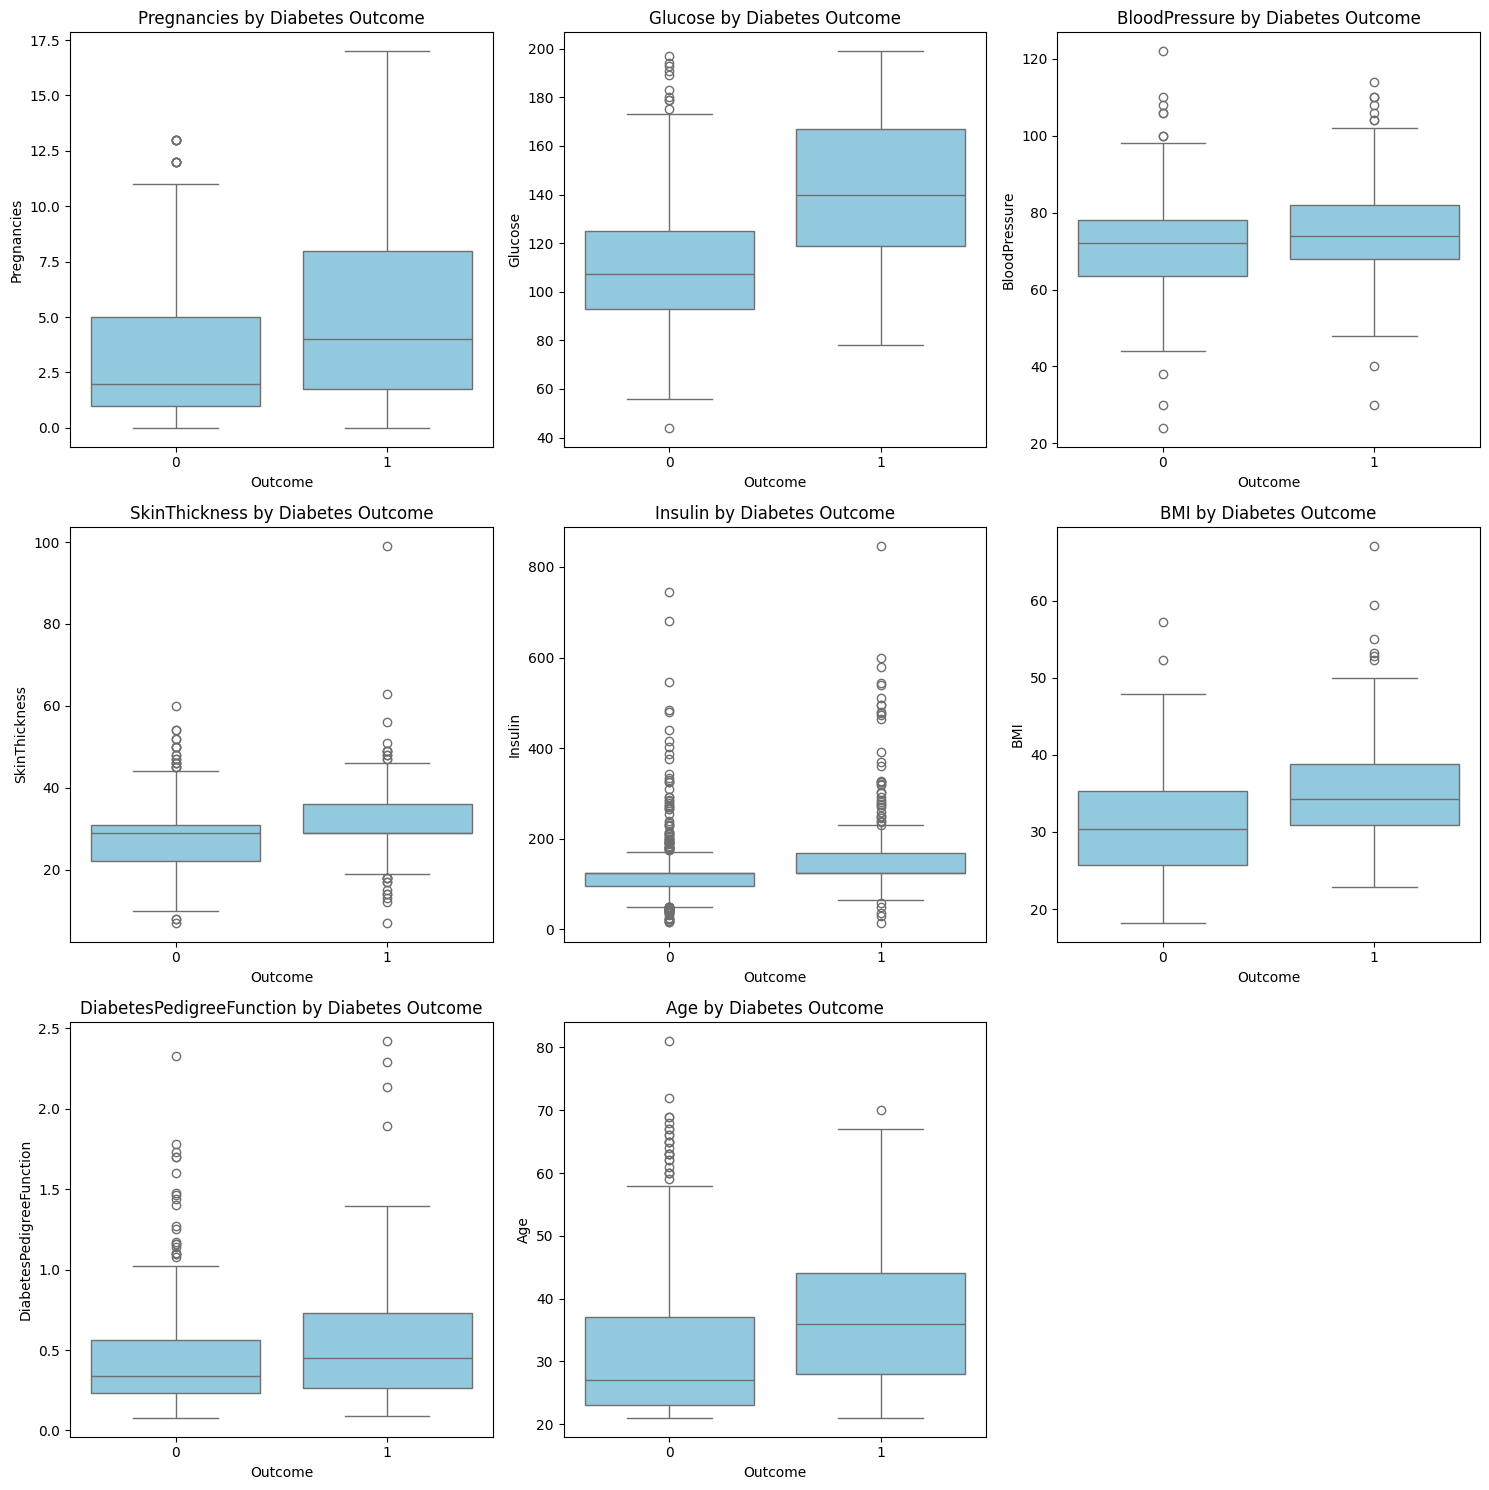

In [44]:
# Target (0 = no diabetes, 1 = diabetes)

plt.figure(figsize=(15, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x="Outcome", y=col, data=df,color="skyblue")
    plt.title(f"{col} by Diabetes Outcome")
plt.tight_layout()
plt.show()


### Correlation Heatmap

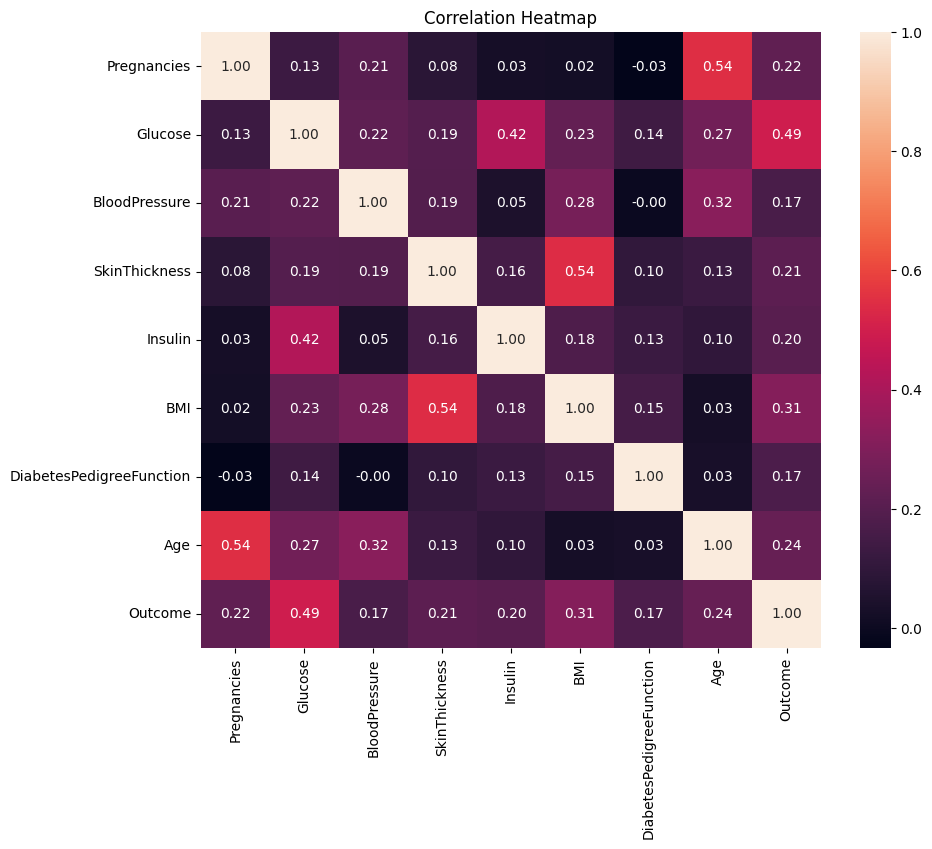

,index,Outcome
0,Outcome,1.000000
1,Glucose,0.492782
2,BMI,0.312038
3,Age,0.238356
4,Pregnancies,0.221898
5,SkinThickness,0.214873
6,Insulin,0.203790
7,DiabetesPedigreeFunction,0.173844
8,BloodPressure,0.165723


In [45]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

corr['Outcome'].sort_values(ascending=False).reset_index()

Glucose shows the strongest correlation with the diabetes outcome, followed by BMI, Age and Pregnancies.

These patterns make sense clinically and help guide feature importance.

## 4. Outlier Analysis

In [46]:
# generate a statistical summary of the numerical columns in a DataFrame
print("DATASET Statistical Summary:")
df.describe()

DATASET Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [47]:
outliers = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

# Outlier counts
pd.Series(outliers).sort_values(ascending=False).reset_index()


,index,0
0,Insulin,346
1,SkinThickness,87
2,DiabetesPedigreeFunction,29
3,BloodPressure,14
4,Age,9
5,BMI,8
6,Pregnancies,4
7,Glucose,0


BloodPressure and Insulin show the most extreme values, which may reflect measurement issues or natural variability.

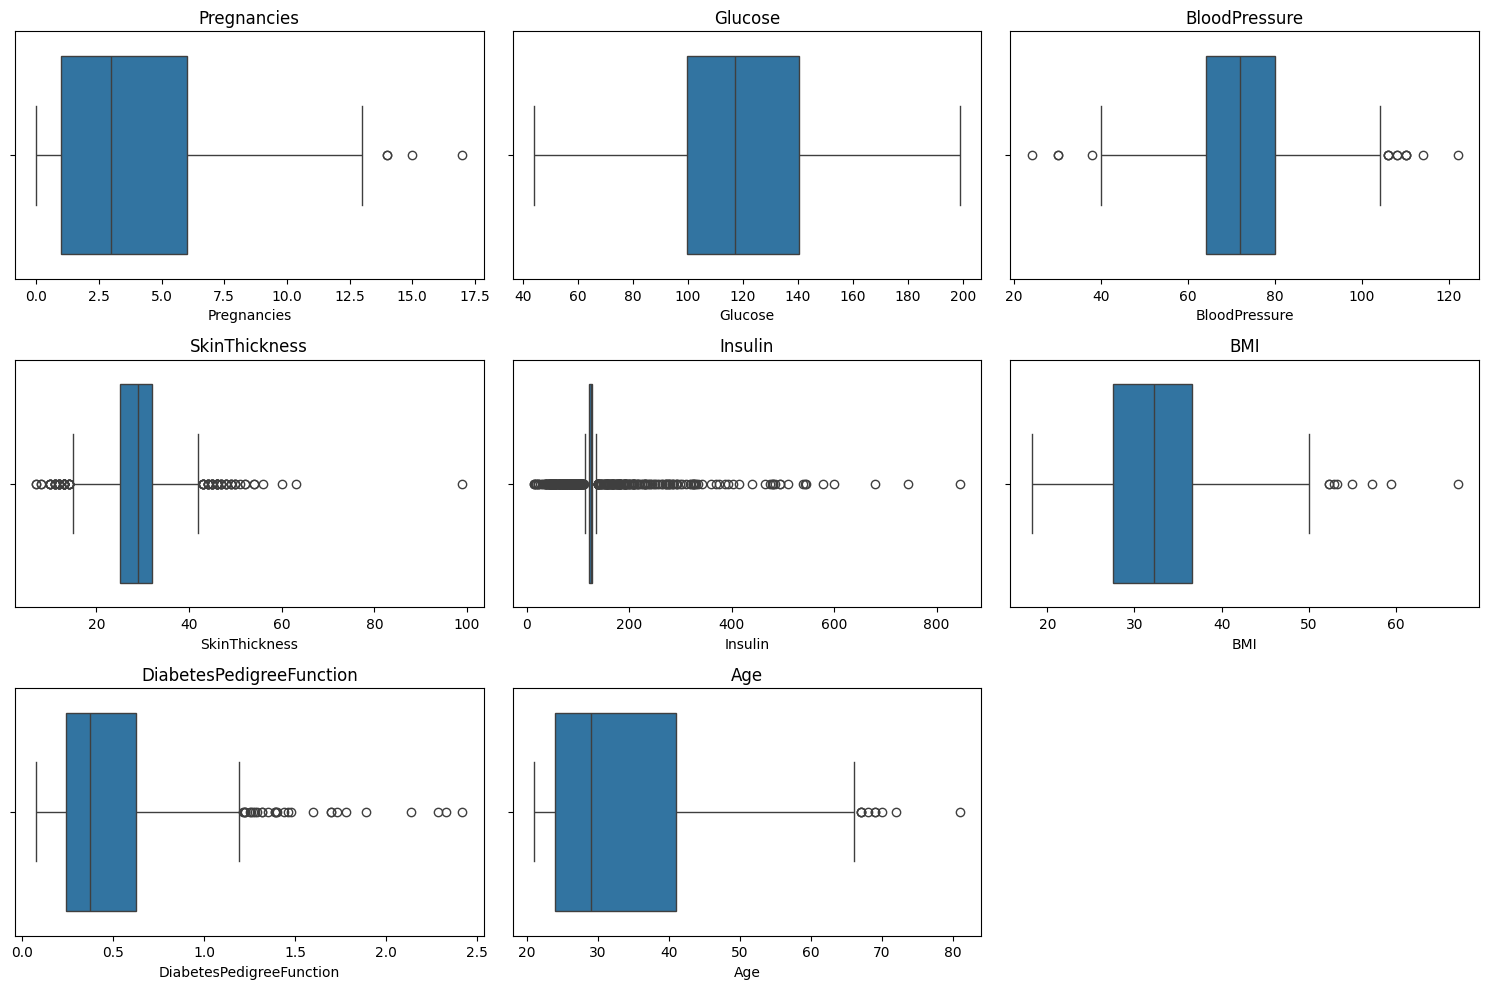

In [48]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


## 5. Preprocessing

*Note:* **Encoding** is not necessary as all variables are numeric

### Train/Test

In [49]:
# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [50]:
print(f"Train: {X_train.shape}")

print(f"Test: {X_test.shape}")

Train: (614, 8)
Test: (154, 8)


## 6. Modeling

### Random Forest Model

In [51]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


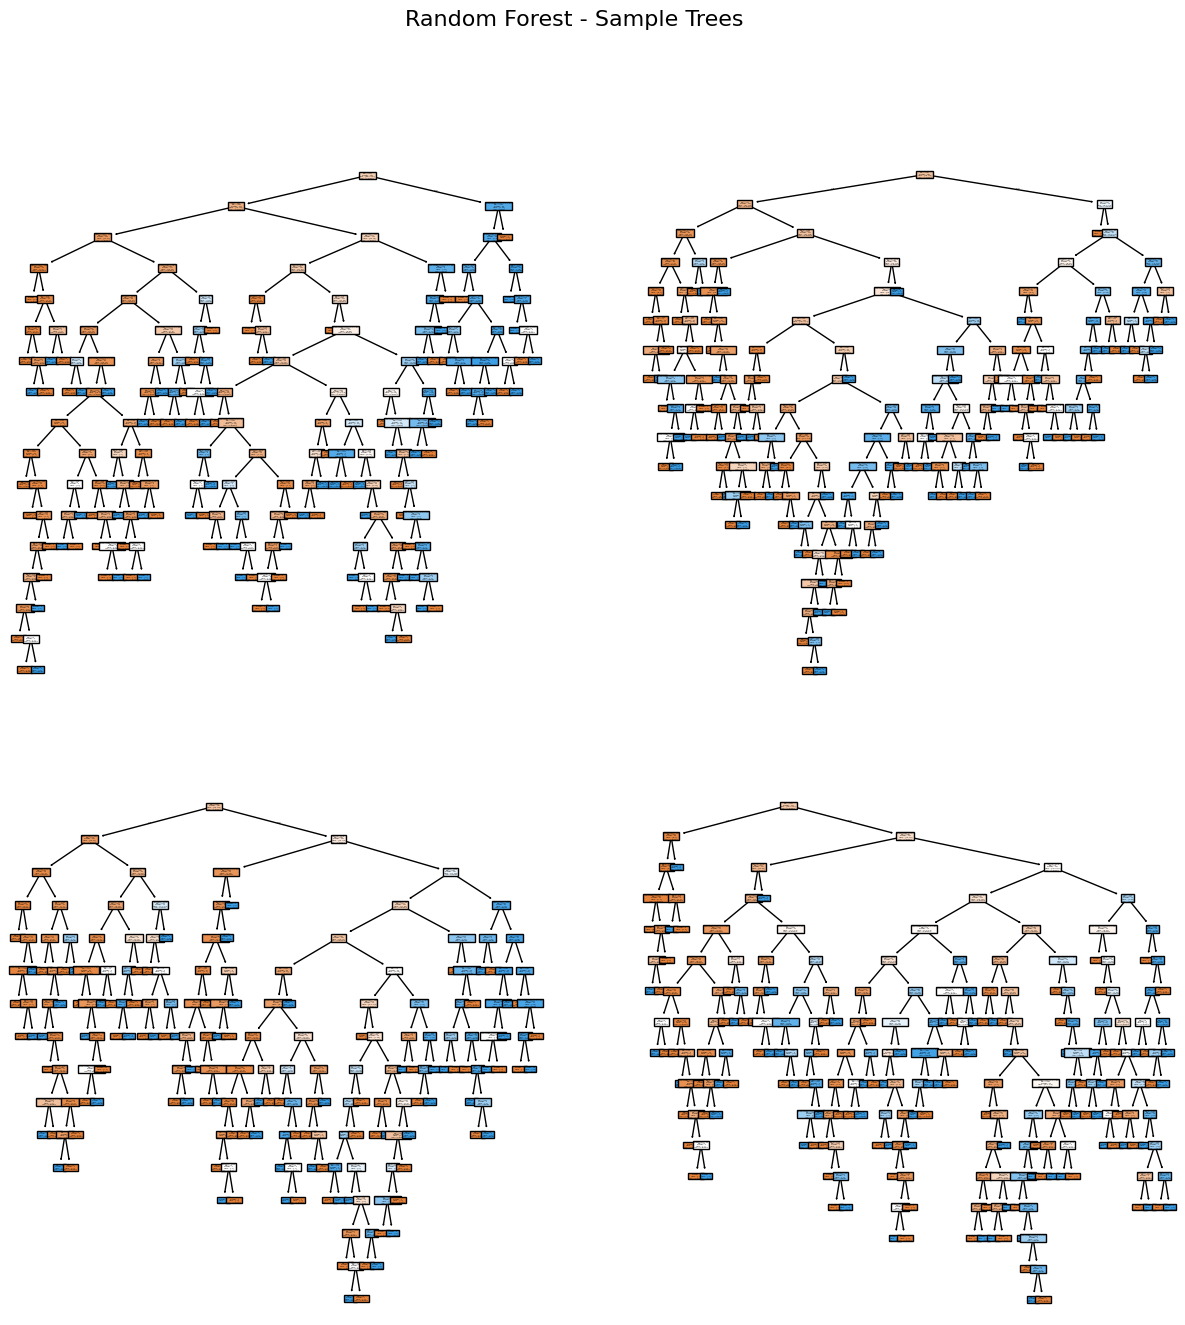

In [52]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))

classes = ["No Diabetes", "Diabetes"]
plot_tree(rf.estimators_[10], ax = axis[0, 0], feature_names = list(X_train.columns), class_names = classes, filled = True)
plot_tree(rf.estimators_[24], ax = axis[0, 1], feature_names = list(X_train.columns), class_names = classes, filled = True)
plot_tree(rf.estimators_[48], ax = axis[1, 0], feature_names = list(X_train.columns), class_names = classes, filled = True)
plot_tree(rf.estimators_[30], ax = axis[1, 1], feature_names = list(X_train.columns), class_names = classes, filled = True)

plt.suptitle("Random Forest - Sample Trees", fontsize=16)
plt.show()

### Accuracy Analysis

In [53]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Baseline ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("")
print("AUC Test:", roc_auc_score(y_test, y_proba_rf))


=== Random Forest Baseline ===
Accuracy: 0.7792207792207793

Confusion Matrix:
[[88 12]
 [22 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154


AUC Test: 0.8191666666666666


In [54]:
# Predictions for both train and test sets
y_pred_train = rf.predict(X_train)

# Metrics
accuracy_test = accuracy_score(y_test, y_pred_rf)
accuracy_train = accuracy_score(y_train, y_pred_train)

f1_score_test = f1_score(y_test, y_pred_rf, average='micro')
f1_score_train = f1_score(y_train, y_pred_train, average='micro')

precision_test = precision_score(y_test, y_pred_rf, average='micro')
precision_train = precision_score(y_train, y_pred_train, average='micro')

recall_test = recall_score(y_test, y_pred_rf, average='micro')
recall_train = recall_score(y_train, y_pred_train, average='micro')

# Print results
print("Accuracy Test:", accuracy_test)
print("F1 score Test:", f1_score_test)
print("Precision Test:", precision_test)
print("Recall Test:", recall_test)
print("")
print("Accuracy Train:", accuracy_train)
print("F1 score Train:", f1_score_train)
print("Precision Train:", precision_train)
print("Recall Train:", recall_train)


Accuracy Test: 0.7792207792207793
F1 score Test: 0.7792207792207793
Precision Test: 0.7792207792207793
Recall Test: 0.7792207792207793

Accuracy Train: 1.0
F1 score Train: 1.0
Precision Train: 1.0
Recall Train: 1.0


### Optimization

In [55]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="roc_auc", n_jobs=-1)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)



Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


In [56]:
# Get best model from GridSearch
rf_opt = grid.best_estimator_

In [57]:
# Predictions
y_pred_opt = rf_opt.predict(X_test)
y_proba_opt = rf_opt.predict_proba(X_test)[:, 1]

print("=== Optimized Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_opt))
print("")
print("Classification Report:")
print(classification_report(y_test, y_pred_opt))
print("")
print("AUC Test:", roc_auc_score(y_test, y_proba_opt))

=== Optimized Random Forest ===
Accuracy: 0.7467532467532467

Confusion Matrix:
[[86 14]
 [25 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.82       100
           1       0.67      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154


AUC Test: 0.8061111111111111


In [58]:
mse_test = mean_squared_error(y_test, y_pred_opt)
rmse_test = np.sqrt(mse_test)

print("MSE Test: ", mse_test)
print("RMSE Test: ", rmse_test)

MSE Test:  0.2532467532467532
RMSE Test:  0.5032362797401965


### Optimized Random Forest Plot- Accuracy vs n_estimators

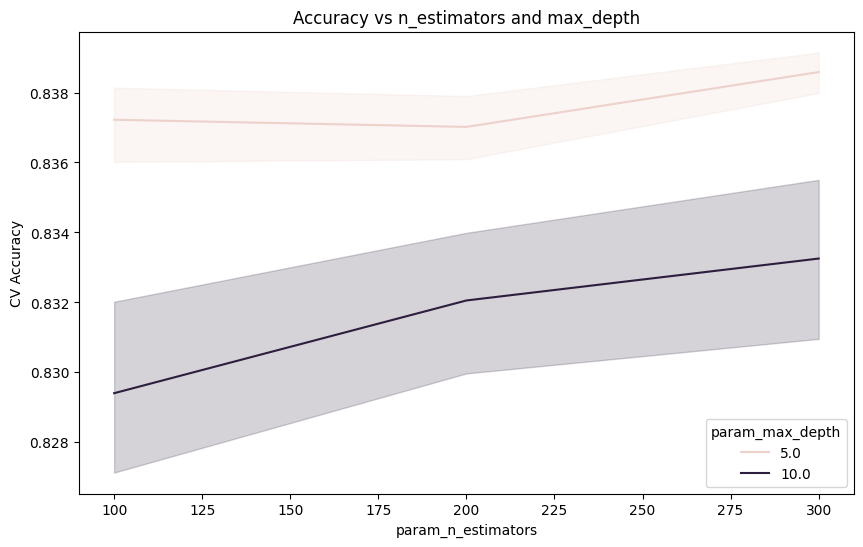

In [59]:
results = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(10,6))
sns.lineplot(x=results["param_n_estimators"], y=results["mean_test_score"], hue=results["param_max_depth"])
plt.title("Accuracy vs n_estimators and max_depth")
plt.ylabel("CV Accuracy")
plt.show()


The accuracy curve demonstrates how adding more trees improves stability and performance up to a point. Beyond ~100–200 trees, gains level off, showing that the model has reached a good balance between accuracy and efficiency.
This validates that tuning hyperparameters helps optimize predictive power.

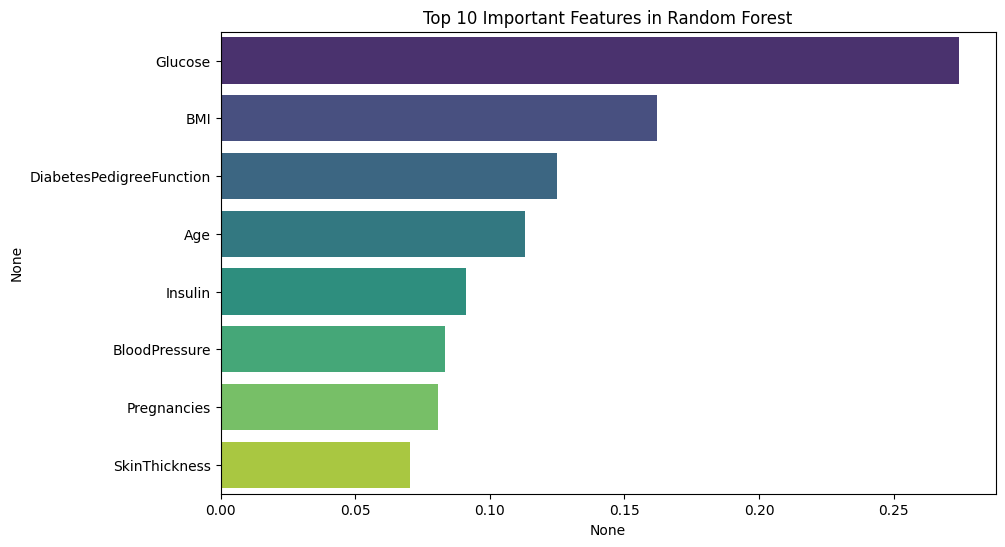

In [60]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index, hue=top_features.index, palette="viridis", legend=False)
plt.title("Top 10 Important Features in Random Forest")
plt.show()


Glucose, BMI, and Age stand out as the strongest contributors, which matches clinical expectations. This confirms the model is learning meaningful patterns and focusing on medically relevant features.

## Final Conclusions
The optimized Random Forest improved performance compared to the baseline Decision Tree. Accuracy reached around 75%, and the AUC was 0.81, showing that the model can distinguish diabetic vs non‑diabetic patients with good reliability.

Feature importance analysis highlighted Glucose as the most influential variable, followed by BMI and Age. This aligns with clinical expectations:

- High glucose levels are a strong indicator of diabetes risk.

- BMI and age also play significant roles in predicting outcomes.

By tuning hyperparameters such as `n_estimators` and `max_depth`, we achieved a balance between accuracy and generalization. The ensemble approach reduced overfitting compared to a single tree and provided more stable predictions.

**Conclusion:** Random Forests offer a robust improvement over Decision Trees for diabetes prediction. The model is ready to use, and further enhancements (e.g., Boosting or advanced ensembles) could push performance even higher.



In [61]:
joblib.dump(rf, "/workspaces/random-forest-msalaverri/models/diabetes_random_forest.pkl")
print("Optimized model saved to /models/diabetes_random_forest.pkl")


Optimized model saved to /models/diabetes_random_forest.pkl
